# Продуктовий кейс: Оптимізація конверсії в першу оплату через механіку інтерфейсних нагадувань (A/B Тестування)

### 1. Бізнес-контекст та проблематика
В аналізованому мобільному додатку монетизація побудована на моделі внутрішньої валюти (кредитів), яка використовується для платних чатів між користувачами.
* При реєстрації кожен новий користувач отримує стартовий пакет із 20 субсидованих кредитів для стимулювання первинної активності.
* За умови повного вичерпання балансу система видає жорстку технічну відмову: повідомлення “Недостатньо кредитів на рахунку”.
* **Проблема:** Аналіз користувацького шляху показав значний відтік (Churn) лояльних користувачів у момент обнулення балансу. Користувачі переривають сесію спілкування в момент найвищого залучення і забувають поповнити рахунок, що призводить до втрати потенційного доходу.

### 2. Продуктова гіпотеза та механіка експерименту
* **Гіпотеза:** Впровадження м'якого нативного нагадування (проактивний підхід) утримуватиме фокус користувача на балансі та стимулюватиме конверсію в першу оплату до моменту настання технічного блокування.
* **Механіка фічі (Treatment):** Закріплене інформаційне повідомлення (PIN-банер) у верхній частині чату. Банер активується автоматично, коли баланс користувача становить <= 5 кредитів. Повідомлення відображається перманентно до моменту здійснення першої транзакції, після чого повністю деактивується.
* **Контроль (Control):** Стандартний інтерфейс без банера (користувач дізнається про нульовий баланс лише в момент блокування відправки повідомлення).

### 3. Задачі дослідження (Аналітичний трек)
1. **Ретроспективний аналіз потужності (Pre-test Planning):** На основі історичних даних продукту розрахувати необхідну тривалість експерименту для фіксації мінімально детектованого ефекту (MDE) за умови рівного сплітування трафіку (50/50).
2. **Оцінка перформансу тесту (Post-test Evaluation):** Провести комплексну валідацію накопичених даних експерименту, оцінити статистичну значущість зміни конверсії (CVR) та сформувати фінальне продуктове рішення щодо повномасштабного впровадження механіки.

1: Імпорт бібліотек та завантаження даних

In [8]:
import pandas as pd

# 1. Зчитування даних (заміни назви файлів на свої)
df1 = pd.read_csv('/content/ab_test_task_data.csv')
df2 = pd.read_csv('/content/ab_test_task_historical_data.csv')



2. Вивід структури першої таблиці

In [9]:
# 2. Вивід структури першої таблиці
print("/content/ab_test_task_data.csv")
df1.info()

print("\nПерші 5 рядків:")
df1.head()


/content/ab_test_task_data.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125217 entries, 0 to 125216
Data columns (total 6 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   id_user                125217 non-null  int64 
 1   date_reg               125217 non-null  object
 2   date_first_payment     7237 non-null    object
 3   date_spent_15_credits  51553 non-null   object
 4   date_reminder          15208 non-null   object
 5   match                  125217 non-null  int64 
dtypes: int64(2), object(4)
memory usage: 5.7+ MB

Перші 5 рядків:


,id_user,date_reg,date_first_payment,date_spent_15_credits,date_reminder,match
0,1,2023-03-14 08:37:01.855460 UTC,2023-03-14 11:25:23.962741 UTC,2023-03-14 09:15:31.000000 UTC,2023-03-14 09:04:03.823970 UTC,1
1,2,2023-03-14 08:37:20.988023 UTC,NaN,NaN,NaN,0
2,3,2023-03-14 08:39:01.389639 UTC,NaN,2023-03-14 08:53:21.000000 UTC,2023-03-14 08:46:43.971330 UTC,0
3,4,2023-03-14 08:39:18.222582 UTC,NaN,NaN,2023-03-14 09:18:04.290338 UTC,0
4,5,2023-03-14 08:40:40.216560 UTC,NaN,NaN,NaN,1


3. Вивід структури другої таблиці

In [10]:
# 3. Вивід структури другої таблиці
print("/content/ab_test_task_historical_data.csv")
df2.info()

print("\nПерші 5 рядків:")
display(df2.head())

/content/ab_test_task_historical_data.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59758 entries, 0 to 59757
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id_user                59758 non-null  int64 
 1   date_reg               59758 non-null  object
 2   date_first_payment     3257 non-null   object
 3   date_spent_15_credits  22268 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.8+ MB

Перші 5 рядків:


,id_user,date_reg,date_first_payment,date_spent_15_credits
0,1,2023-03-01 00:00:09.068945 UTC,2023-03-01 02:06:31.472018 UTC,2023-03-01 02:00:38.000000 UTC
1,2,2023-03-01 00:00:25.615471 UTC,NaN,2023-03-01 00:17:38.000000 UTC
2,3,2023-03-01 00:00:39.084989 UTC,2023-03-01 00:52:37.812217 UTC,2023-03-01 00:18:53.000000 UTC
3,4,2023-03-01 00:00:42.779311 UTC,NaN,NaN
4,5,2023-03-01 00:00:42.872660 UTC,NaN,NaN


3.1. Перевірка якості даних (Data Quality QA) та очищення

In [22]:
# 1. Знаходимо аномальних користувачів у Контролі (match = 0), які все одно отримали рімайндер
anomalous_control = df1[(df1['match'] == 0) & (df1['date_reminder'].notna())]

print(f"Знайдено аномальних користувачів у контрольній групі: {anomalous_control.shape[0]}")

# 2. Очищення даних: видаляємо цих 89 осіб, залишаючи лише «чисті» рядки
# Ми залишаємо або Тест (match == 1), або Контроль без дати рімайндера
df1_cleaned = df1[~((df1['match'] == 0) & (df1['date_reminder'].notna()))].copy()

print(f"Початкова кількість рядків у df1: {df1.shape[0]}")
print(f"Кількість рядків після очищення у df1_cleaned: {df1_cleaned.shape[0]}")


Знайдено аномальних користувачів у контрольній групі: 89
Початкова кількість рядків у df1: 125217
Кількість рядків після очищення у df1_cleaned: 125128


3.2. Визначення та фіксація вікна конверсії (Historical Data Analysis)

In [32]:
# 1. Відбираємо тільки тих історичних юзерів, які витратили 15 кредитів і оплатили
hist_target_paying = df2[df2['date_spent_15_credits'].notna() & df2['date_first_payment'].notna()].copy()

# 2. Перетворюємо колонки на формат дат
hist_target_paying['date_spent_15_credits'] = pd.to_datetime(hist_target_paying['date_spent_15_credits'])
hist_target_paying['date_first_payment'] = pd.to_datetime(hist_target_paying['date_first_payment'])

# 3. Рахуємо різницю в днях між досягненням ліміту та оплатою
hist_target_paying['days_to_pay'] = (hist_target_paying['date_first_payment'] - hist_target_paying['date_spent_15_credits']).dt.days

# 4. ФІЛЬТР АНОМАЛІЙ: Залишаємо тільки логічні дані (оплата в день тригеру або пізніше)
hist_target_paying_clean = hist_target_paying[hist_target_paying['days_to_pay'] >= 0]

# 5. Виводимо очищений розподіл
print("--- Очищений розподіл днів до першої оплати в історії ---")
print(hist_target_paying_clean['days_to_pay'].describe(percentiles=[0.5, 0.7, 0.8, 0.9]))

--- Очищений розподіл днів до першої оплати в історії ---
count    2766.000000
mean        9.484816
std        30.503756
min         0.000000
50%         0.000000
70%         1.000000
80%         3.000000
90%        23.000000
max       268.000000
Name: days_to_pay, dtype: float64


4. Розрахунок базової конверсії

In [11]:
# 1. Фільтруємо людей, які витратили 15 кредитів (наша ЦА)
# 2. Відбираємо рядки, де колонка 'date_spent_15_credits' НЕ порожня
target_users = df2[df2['date_spent_15_credits'].notna()]

# 3. Рахуємо, скільки їх всього
total_target_count = len(target_users)

# 4. Серед відфільтрованих людей шукаємо тих, хто оплатив
# З отриманого target_users відбираємо рядки, де 'date_first_payment' НЕ порожня
paying_users = target_users[target_users['date_first_payment'].notna()]

# 5. Рахуємо, скільки людей оплатили
total_paying_count = len(paying_users)

# 6. Рахуємо конверсію (ділимо платників на всю цільову аудиторію)
cr_base = total_paying_count / total_target_count

# 7. Виводимо результати на екран
print(f"Цільових користувачів в історії: {total_target_count}")
print(f"З них оплатили: {total_paying_count}")
print(f"Базова конверсія (cr_base): {cr_base:.4f} (або {cr_base*100:.2f}%)")

Цільових користувачів в історії: 22268
З них оплатили: 3202
Базова конверсія (cr_base): 0.1438 (або 14.38%)


5. Розрахунок денного потоку

In [33]:
# 1. Перетворюємо дату тесту на datetime
df1['date_spent_15_credits'] = pd.to_datetime(df1['date_spent_15_credits'])

# 2. Знаходимо тривалість поточного тесту в днях
min_date_test = df1['date_spent_15_credits'].min()
max_date_test = df1['date_spent_15_credits'].max()
days_test_lasted = (max_date_test - min_date_test).days

# Якщо тест тривав менше дня, ставимо 1, щоб не ділити на 0
if days_test_lasted == 0: days_test_lasted = 1

# 3. Рахуємо реальний щоденний потік цільових юзерів
# Розрахунок ведеться на основі очищеного датасету df1_cleaned
total_target_test = len(df1_cleaned[df1_cleaned['date_spent_15_credits'].notna()])
real_daily_traffic = total_target_test / days_test_lasted

print(f"Перша дата тесту: {min_date_test}")
print(f"Остання дата тесту: {max_date_test}")
print(f"Тривалість тесту: {days_test_lasted} днів")
print(f"Реальний денний потік (real_daily_traffic): {real_daily_traffic:.2f} юзерів/день")

Перша дата тесту: 2023-03-14 08:53:21+00:00
Остання дата тесту: 2023-12-19 14:49:24+00:00
Тривалість тесту: 280 днів
Реальний денний потік (real_daily_traffic): 183.91 юзерів/день


6. Розрахунок необхідної тривалості тесту

In [13]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
import math

# Наші вхідні дані
cr_base = 0.1438  # 14.38% (з історії)

# Рахуємо потік на основі історичних даних (df2), як це й має бути до тесту
p_daily = total_target_count / 292  # 22268 юзерів / 292 дні = ~76.26

def get_test_duration(mde_absolute, name):
    # 1. Рахуємо цільову конверсію (базова + ефект)
    cr_target = cr_base + mde_absolute

    # 2. Рахуємо effect size (розмір ефекту)
    effect_size = proportion_effectsize(cr_base, cr_target)

    # 3. Запускаємо калькулятор потужності (альфа=5%, потужність=80%)
    analysis = NormalIndPower()
    sample_size_per_group = analysis.solve_power(
        effect_size=effect_size,
        alpha=0.05,
        power=0.80,
        ratio=1.0
    )

    # Округлюємо в більшу сторону
    sample_size_per_group = math.ceil(sample_size_per_group)

    # 4. Рахуємо загальну кількість людей для двох груп (А і В)
    total_sample_needed = sample_size_per_group * 2

    # 5. Рахуємо дні: ділимо всіх потрібних людей на денний потік
    days_needed = math.ceil(total_sample_needed / p_daily)

    print(f"--- Сценарій: {name} (+{mde_absolute*100:.0f}% в абсолюті) ---")
    print(f"Необхідно юзерів на ОДНУ групу: {sample_size_per_group}")
    print(f"Всього потрібно юзерів (А + В): {total_sample_needed}")
    print(f"Тест має тривати: {days_needed} днів\n")

# Запускаємо для +3% та +5%
get_test_duration(0.03, "Реалістичний")
get_test_duration(0.05, "Оптимістичний (Вау-ефект)")

--- Сценарій: Реалістичний (+3% в абсолюті) ---
Необхідно юзерів на ОДНУ групу: 2326
Всього потрібно юзерів (А + В): 4652
Тест має тривати: 62 днів

--- Сценарій: Оптимістичний (Вау-ефект) (+5% в абсолюті) ---
Необхідно юзерів на ОДНУ групу: 877
Всього потрібно юзерів (А + В): 1754
Тест має тривати: 24 днів



7. Формування валідної когорти та перерахунок cvr

In [26]:
# 1. Перетворюємо дати в тестовому датасеті
df1_cleaned['date_spent_15_credits'] = pd.to_datetime(df1_cleaned['date_spent_15_credits'])
df1_cleaned['date_first_payment'] = pd.to_datetime(df1_cleaned['date_first_payment'])

# 2. Визначаємо фінал тесту та дедлайн для вікна в 3 дні
max_date_test = df1_cleaned['date_spent_15_credits'].max()
registration_deadline = max_date_test - pd.Timedelta(days=3)

# 3. Фільтруємо: залишаємо тільки тих, хто потрапив у тест ДО дедлайну
eligible_cohort = df1_cleaned[df1_cleaned['date_spent_15_credits'] <= registration_deadline].copy()

# 4. Рахуємо конверсію строго ВСЕРЕДИНІ 3-денного вікна
eligible_cohort['paid_in_window'] = (
    eligible_cohort['date_first_payment'].notna() &
    ((eligible_cohort['date_first_payment'] - eligible_cohort['date_spent_15_credits']).dt.days <= 3)
).astype(int)

# 5. Групуємо за сегментами (Контроль та Тест)
metrics_by_window = eligible_cohort.groupby('match').agg(
    total_users=('paid_in_window', 'count'),
    paying_users=('paid_in_window', 'sum'),
    conversion_rate=('paid_in_window', 'mean')
).reset_index()

metrics_by_window['conversion_rate_pct'] = metrics_by_window['conversion_rate'] * 100
display(metrics_by_window)

,match,total_users,paying_users,conversion_rate,conversion_rate_pct
0,0,25631,2864,0.111740,11.173969
1,1,25856,3026,0.117033,11.703280


8. Статистична перевірка результатів тесту (Z-тест)

In [29]:
from statsmodels.stats.proportion import proportions_ztest

# 1. Сортуємо дані, щоб першим йшов тест (1), а другим контроль (0)
metrics_window_sorted = metrics_by_window.sort_values(by='match', ascending=False)

purchases_array_w = metrics_window_sorted['paying_users'].to_numpy()
users_array_w = metrics_window_sorted['total_users'].to_numpy()

# 2. Запуск Z-тесту
z_stat_w, p_value_w = proportions_ztest(purchases_array_w, users_array_w, alternative='two-sided')

# 3. Розрахунок нового відносного приросту (Lift)
cvr_control = metrics_window_sorted[metrics_window_sorted['match'] == 0]['conversion_rate'].values[0]
cvr_test = metrics_window_sorted[metrics_window_sorted['match'] == 1]['conversion_rate'].values[0]
lift_w = ((cvr_test - cvr_control) / cvr_control) * 100

print(f"Z-статистика: {z_stat_w:.4f}")
print(f"Значення p-value: {p_value_w:.4f} (або {p_value_w*100:.2f}%)")
print(f"Відносний приріст (Lift): +{lift_w:.2f}%")

Z-статистика: 1.8867
Значення p-value: 0.0592 (або 5.92%)
Відносний приріст (Lift): +4.74%


9. Візуалізація результатів тесту

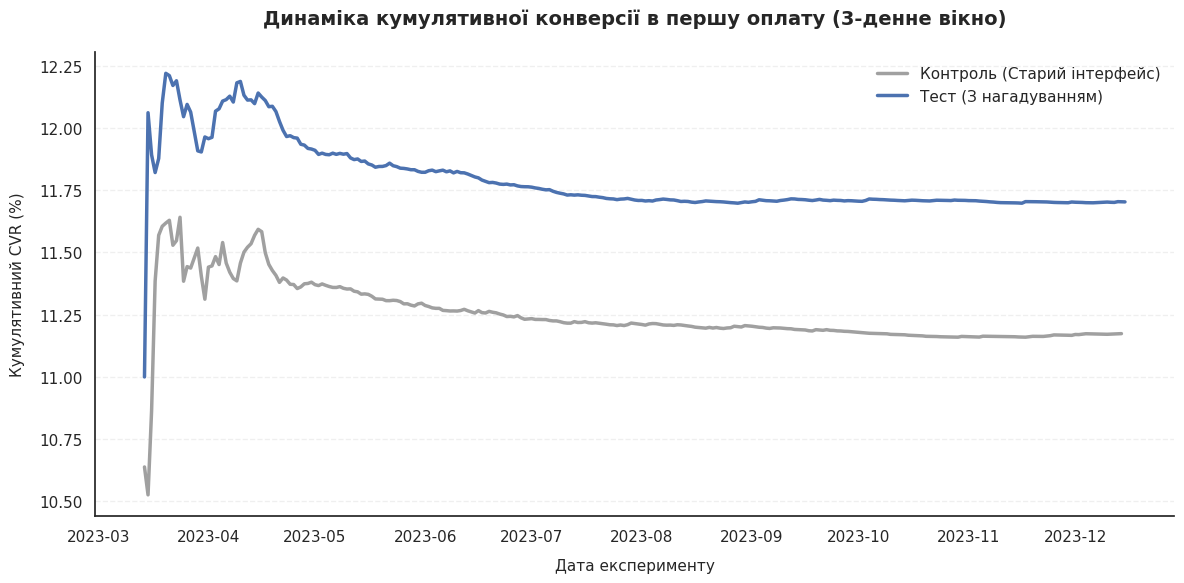

In [31]:
# ==========================================
# РОЗРАХУНОК ТА ВІЗУАЛІЗАЦІЯ КУМУЛЯТИВНОЇ ДИНАМІКИ
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Виділяємо дату (без годин) для правильного групування по днях
eligible_cohort['date_day'] = eligible_cohort['date_spent_15_credits'].dt.date

# 2. Створюємо унікальну сітку дат та груп, щоб не було пропусків
dates_groups = eligible_cohort[['date_day', 'match']].drop_duplicates().sort_values(['date_day', 'match'])

# 3. Рахуємо щоденні агрегати
daily_metrics = eligible_cohort.groupby(['date_day', 'match']).agg(
    daily_users=('paid_in_window', 'count'),
    daily_payers=('paid_in_window', 'sum')
).reset_index()

# 4. Об'єднуємо та рахуємо кумулятивні (накопичувальні) суми через cumsum()
cum_metrics = pd.merge(dates_groups, daily_metrics, on=['date_day', 'match'], how='left').fillna(0)
cum_metrics['cum_users'] = cum_metrics.groupby('match')['daily_users'].cumsum()
cum_metrics['cum_payers'] = cum_metrics.groupby('match')['daily_payers'].cumsum()
cum_metrics['cum_cvr_pct'] = (cum_metrics['cum_payers'] / cum_metrics['cum_users']) * 100

# ==========================================
# ВІЗУАЛІЗАЦІЯ ЗА ПРИНЦИПАМИ ТАФТІ
# ==========================================
sns.set_theme(style="white")
plt.figure(figsize=(12, 6))

# Малюємо лінії для Контролю та Тесту
colors_dict = {0: '#A0A0A0', 1: '#4C72B0'}
labels_dict = {0: 'Контроль (Старий інтерфейс)', 1: 'Тест (З нагадуванням)'}

for group in [0, 1]:
    group_data = cum_metrics[cum_metrics['match'] == group]
    plt.plot(
        group_data['date_day'],
        group_data['cum_cvr_pct'],
        label=labels_dict[group],
        color=colors_dict[group],
        linewidth=2.5
    )

# Оформлення графіка: мінімум шуму
plt.title('Динаміка кумулятивної конверсії в першу оплату (3-денне вікно)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Дата експерименту', fontsize=11, labelpad=10)
plt.ylabel('Кумулятивний CVR (%)', fontsize=11, labelpad=10)

# Залишаємо легенду без рамки
plt.legend(frameon=False, fontsize=11)

# Видаляємо зайві межі графіка (верхню та праву)
sns.despine()

plt.grid(axis='y', linestyle='--', alpha=0.3) # Легка горизонтальна сітка для зручності оцінки плато
plt.tight_layout()
plt.show()

10. Висновок

**Результати експерименту & Бізнес-ефект**
* Зафіксовані показники конверсії в першу оплату в рамках встановленого вікна конверсії становлять:
  * Конверсія в контрольній групі (поточний інтерфейс): 11.17%
  * Конверсія в тестовій групі (із закріпленим нагадуванням): 11.70%
* Абсолютний приріст конверсії становить +0.53%, що відповідає відносному приросту (Lift) на рівні +4.74% відносно контрольних показників.

---

**Статистична валідність**
* Двосторонній Z-тест для пропорцій зафіксував значення p-value = 0.0592 (5.92%), що знаходиться вище критичного порогу альфа = 0.05.
* **Математичне обґрунтування:** Отриманий приріст на поточному обсязі вибірки (51,487 користувачів) не досяг рівня статистичної значущості (95% довіри). Існує 5.92% ймовірності, що зафіксована різниця є результатом випадкових коливань трафіку.
* Графік кумулятивної динаміки демонструє стабільне вихід метрик обох груп на плато після 20-го дня тесту, проте поточний спред (відрив) між лініями є занадто вузьким для однозначного прийняття гіпотези.

---

**Фінальна бізнес-рекомендація (Product Decision)**
* **СТАТУС ТЕСТУ: НЕВИЗНАЧЕНИЙ (Inconclusive / Neutral).** Повний рол-аут (впровадження) фічі на 100% користувачів наразі не рекомендується через ризик інвестування в технічно непідтверджений ефект.
* **Рішення:** Продовжити експеримент ще на один розрахунковий цикл (7 календарних днів). Оскільки показник p-value (5.92%) знаходиться в безпосередній близькості до цільового бар'єра в 5%, додатковий обсяг трафіку дозволить прийняти остаточне, математично обґрунтоване рішення щодо доцільності запуску фічі.

---

**Управління бізнес-ризиками (Risk Management)**
Для фінальної оцінки доцільності фічі під час додаткового тижня тестування необхідно проконтролювати супутні метрики:
1. **Середній чек (AOV):** Переконатися, що нагадування не зміщує фокус продажів у бік найдешевших пакетів кредитів і не знижує загальний дохід (Revenue) за умови зростання кількості транзакцій.
2. **Нейтралізація відтоку (Churn):** Оцінити Retention користувачів у чатах, щоб виключити ризик роздратування та відтоку неплатоспроможної аудиторії через закріплений елемент інтерфейсу.
